<a href="https://colab.research.google.com/github/Bunty-Bot/deep_learning_MBFProject/blob/main/DL_Test_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# Importing all the required libraries
import os
import re
import matplotlib.pyplot as plt

In [3]:
# Cloning the git repository with the Data
!git clone https://git.wur.nl/bioinformatics/grs34806-deep-learning-project-data.git
os.chdir("grs34806-deep-learning-project-data")

fatal: destination path 'grs34806-deep-learning-project-data' already exists and is not an empty directory.


In [30]:
# Analysing the data structure for further analysis
seqfile = "len100_200_n1000.seq"
posfile = "len100_200_n1000.pos"

print("First 5 entries from seqfile:")
with open(seqfile, 'r') as f:
  for k, line in enumerate(f):
    if k < 5:
      print(line.strip())
    else:
      break

print("\nFirst 5 entries from posfile:")
with open(posfile, 'r') as f:
  for k, line in enumerate(f):
    if k < 5:
      print(line.strip())
    else:
      break

First 5 entries from seqfile:
seq1	MQICGLVKTAKTPSCWSTVPYGREVGSPMTHQQHETERLQYKRWSGCNGFHGGKIRQYLFNMQGTDCKTDQTAGMAISESFLDFQGDHSYEELNAHPIFQTWPPNNSIRDDCL
seq2	MTGVKGTYGTPNVFQSTNEVSSGDQKIPWPKTEQTACLWGLPLSQFPIRKVIREIDNANTAIINLSLQDPNGNCNCMSKDSYTWWFRYARFHRCGRCIWMPWNGDRCDKYEKYYTDNMLYPEPNQLDSDRIKRGACHSDGMTDHGRDNGKWCCFVINLDDPSHTLP
seq3	MCHYAWCMWNTGCHWGINEEWAFHDKDLQGFPRKLHRPTRPKHYDTCLDDFSMCSTMCEARNVQRYNNWDRVRNRSQNVFDSYQDISRRAHFDSRQDDVLTDTKCYTNEFCHCELSPDMLFLGRTPNTSQAKPHIHVITRPNCNCHPRNQWATMIYYQWKLRQESETVIDQNKGCFSIFAKKEAGTWGIEFTLLYAK
seq4	MQVLNSMLDKVTQDWGKKCGLVKTAKTPQFWILVRRNPSVPVAAAMSINCFSTPRHELYKVRMMGWGSLYKNRQTYNSLSTLMRHSSMPSGVTDCVYWAVFGESIDDDWAWWLRADNDFLWFGNDTDRSIGLYINSCSRVDWMWANHFSE
seq5	MKNHQGCCPSTVGFRNDAQYQISWDVPMAWLWLDRPVKLYMFHFDTEMRDHFKIQSRVNQPDTYPVETTEPFAMVREPEAWSVTNRWSQNSRTWRNMCNTLIINNFEKYDANYVWRWQYWWERQGKRLPHWLPC

First 5 entries from posfile:
seq1
seq4
seq7
seq9
seq10


In [35]:
def read(seqfile, posfile):
    """
    Read a dataset from provided sequence and positive file.

    Args:
        seqfile : sequence file with one sequence per line
        posfile : list of positive IDs (one per line)

    Returns:
        sequences : list[str]   amino acid sequences
        labels    : list[int]   1 = functional,  0 = not functional
    """
    seq_dict = {}

    with open(seqfile) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Using regex function extracting the sequence
            match = re.match(r"(seq\d+)\t([A-Z]+)", line)
            if not match:
                continue

            pid, seq = match.groups()

            if pid in seq_dict:
                raise ValueError(f"Duplicate ID found: {pid}")

            seq_dict[pid] = seq

    pos_ids = set()
    with open(posfile) as f:
        for line in f:
            pid = line.strip()
            if pid:
                pos_ids.add(pid)

    sequences = []
    labels = []

    for pid, seq in seq_dict.items():
        sequences.append(seq)
        labels.append(1 if pid in pos_ids else 0)

    return sequences, labels

In [40]:
def plot_label_distribution(labels, title="Positive and Negatives in len100_200_n1000 Dataset"):
    """
    Plot the distribution of positive and negative labels.

    Args:
        labels (list[int]): Binary labels where 1 = positive and 0 = negative.
        title (str): Plot title.

    Returns:
        None. Displays the bar chart.
    """
    if len(labels) == 0:
        raise ValueError("labels is empty; cannot plot class distribution.")

    counts = [sum(labels), len(labels) - sum(labels)]
    total = len(labels)

    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(
        ["Positive (functional)", "Negative (not functional)"],
        counts,
        color=["#2a9d8f", "#e76f51"],
        edgecolor="white",
        linewidth=0.8,
    )

    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{count} ({100 * count / total:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=11,
        )

    ax.set_ylabel("Number of sequences")
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, max(counts) * 1.15)

    plt.tight_layout()
    plt.show()

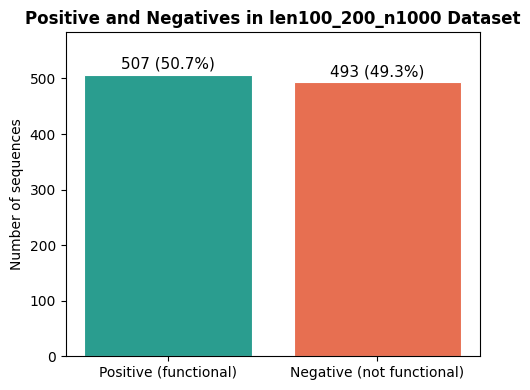

In [41]:
seq, label = read(seqfile, posfile)
plot_label_distribution(label)


['...']
